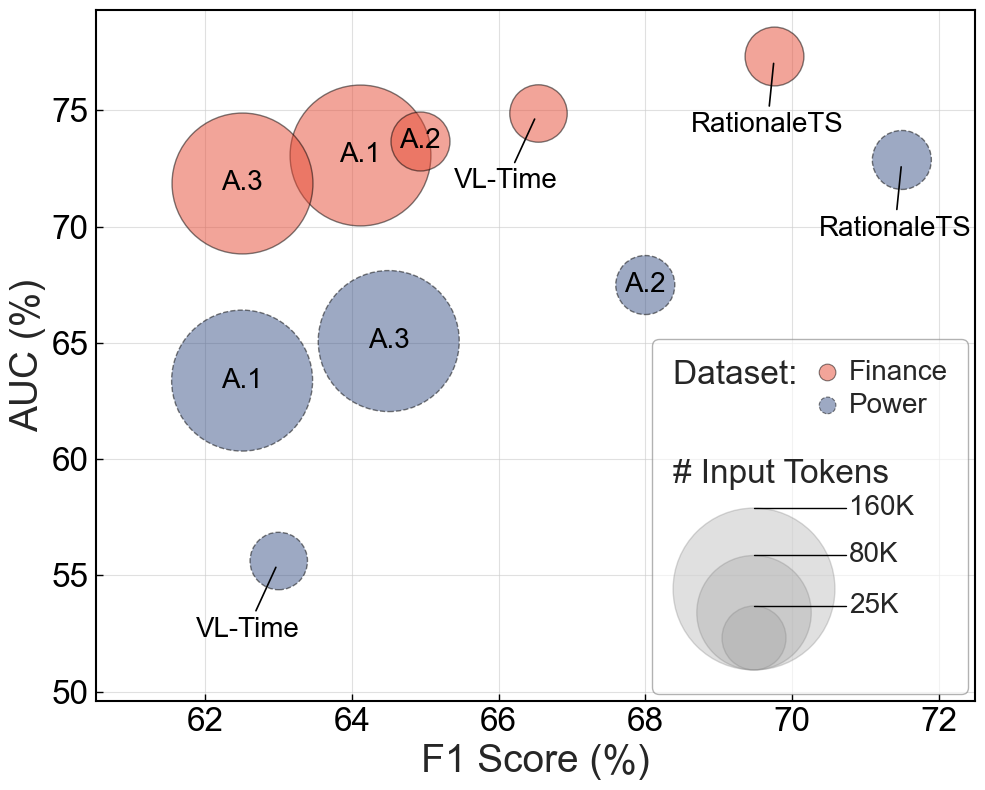

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredOffsetbox, DrawingArea, TextArea, VPacker, HPacker

# 1. 准备数据
data = [
    {'Method': 'RationaleTS',   'Dataset': 'Finance', 'Tokens': 26893,  'F1': 69.76, 'AUC': 77.32},
    {'Method': 'A.1',     'Dataset': 'Finance', 'Tokens': 154307, 'F1': 64.11, 'AUC': 73.08},
    {'Method': 'A.2',     'Dataset': 'Finance', 'Tokens': 27034,  'F1': 64.92, 'AUC': 73.69},
    {'Method': 'A.3',     'Dataset': 'Finance', 'Tokens': 154408, 'F1': 62.50, 'AUC': 71.88},
    {'Method': 'VL-Time', 'Dataset': 'Finance', 'Tokens': 25669,  'F1': 66.53, 'AUC': 74.90},
    {'Method': 'RationaleTS',   'Dataset': 'Power',      'Tokens': 27069,  'F1': 71.50, 'AUC': 72.87},
    {'Method': 'A.1',     'Dataset': 'Power',      'Tokens': 154579, 'F1': 62.50, 'AUC': 63.38},
    {'Method': 'A.2',     'Dataset': 'Power',      'Tokens': 27107,  'F1': 68.00, 'AUC': 67.49},
    {'Method': 'A.3',     'Dataset': 'Power',      'Tokens': 154661, 'F1': 64.50, 'AUC': 65.08},
    {'Method': 'VL-Time', 'Dataset': 'Power',      'Tokens': 25655,  'F1': 63.00, 'AUC': 55.62},
]
df = pd.DataFrame(data)

# 2. 设置画布风格
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 8))

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

ax.tick_params(
    axis='both', which='major', direction='in', bottom=True, left=True,
    length=5, width=1, colors='black', pad=5, labelsize=24
)

# --- 关键修改：定义数据集颜色 ---
# Finance 使用之前的红色，Power 使用深蓝色
dataset_colors = {
    'Finance': '#E64B35', # 红色
    'Power':   '#3C5488'  # 蓝色 (Nature风格深蓝)
}

dataset_style = {
    'Finance': {'edgecolor': 'black', 'width': 1, 'linestyle': '-',  'label': 'Finance'},
    'Power':   {'edgecolor': 'black', 'width': 1, 'linestyle': '--', 'label': 'Power'}
}

# 3. 绘制气泡
scale_factor = 15
external_label_methods = ['RationaleTS', 'VL-Time']

for i, row in df.iterrows():
    style = dataset_style[row['Dataset']]

    # --- 关键修改：根据数据集获取颜色 ---
    c = dataset_colors[row['Dataset']]

    ax.scatter(
        x=row['F1'], y=row['AUC'], s=row['Tokens'] / scale_factor,
        color=c, # 应用颜色
        edgecolors=style['edgecolor'], linewidths=style['width'],
        linestyle=style['linestyle'], alpha=0.5, # 稍微提高一点不透明度让蓝色更明显
        zorder=2
    )

    if row['Method'] in external_label_methods:
        ax.annotate(
            row['Method'],
            xy=(row['F1'], row['AUC']),
            xytext=(-60, -40),
            textcoords='offset points',
            arrowprops=dict(arrowstyle='-', color='black', linewidth=1.2, shrinkB=5),
            fontsize=20,
            color='black',
            ha='left', va='top',
            zorder=4
        )
    else:
        ax.text(row['F1'], row['AUC'], row['Method'], fontsize=20,
                ha='center', va='center', color='black', zorder=3)

# ==============================================================================
# 4. 构建图例
# ==============================================================================

# --- A. Dataset 图例 ---

dataset_title = TextArea("Dataset: ", textprops=dict(fontsize=24))

ds_items_list = []
for ds_name, style in dataset_style.items():
    # --- 关键修改：图例颜色也跟随数据集 ---
    ds_color = dataset_colors[ds_name]

    # 图标
    da = DrawingArea(20, 15, 0, 0)
    p = Circle((10, 8), 6,
               facecolor=ds_color, # 设置图例填充色
               edgecolor='black',
               linewidth=0.8,
               linestyle=style['linestyle'],
               alpha=0.5) # 保持和主图一致的透明度
    da.add_artist(p)

    # 文字
    ta = TextArea(ds_name, textprops=dict(fontsize=20))

    item = HPacker(children=[da, ta], align="center", pad=0, sep=5)
    ds_items_list.append(item)

ds_items_column = VPacker(children=ds_items_list, align="left", pad=0, sep=5)

dataset_packer = HPacker(children=[dataset_title, ds_items_column], align="top", pad=0, sep=5)


# --- B. Size 图例 (颜色设为灰色，避免混淆) ---
sizes_to_show = [160000, 80000, 25000]
max_val = max(sizes_to_show)
max_area = max_val / scale_factor
max_radius = np.sqrt(max_area / np.pi)

da_height = max_radius * 2 + 10
da_width = max_radius * 2 + 50
size_da = DrawingArea(da_width, da_height, 0, 0)
center_x = max_radius

for val in sizes_to_show:
    area = val / scale_factor
    radius = np.sqrt(area / np.pi)
    center_y = radius + 2

    # 这里将Size图例的颜色设为中性灰，或者保持红色也可以
    # 为了看起来不乱，建议设为灰色，或者选一个中间色
    circle = Circle((center_x, center_y), radius,
                    facecolor='#999999', # 灰色
                    edgecolor='gray', alpha=0.3, linewidth=1)
    size_da.add_artist(circle)

    top_y = center_y + radius
    label_text = f'{int(val/1000)}K'
    line = Line2D([center_x, center_x + max_radius + 8], [top_y, top_y], color='black', linewidth=1)
    size_da.add_artist(line)
    from matplotlib.text import Text
    text = Text(center_x + max_radius + 10, top_y, label_text, ha='left', va='center', fontsize=20)
    size_da.add_artist(text)

size_legend_packer = VPacker(children=[
    TextArea("# Input Tokens", textprops=dict(fontsize=24)),
    size_da
], align="left", pad=0, sep=5)


# --- C. 组合并添加 ---
final_packer = VPacker(children=[dataset_packer, TextArea(" "), size_legend_packer],
                       align="left", pad=5, sep=10)

anchored_box = AnchoredOffsetbox(
    loc='lower right',
    child=final_packer,
    pad=0.5,
    frameon=True,
    bbox_to_anchor=(1, 0),
    bbox_transform=ax.transAxes,
    borderpad=1.0
)
anchored_box.patch.set_boxstyle("round,pad=0.5")
anchored_box.patch.set_facecolor("white")
anchored_box.patch.set_alpha(0.6)
anchored_box.patch.set_edgecolor("gray")

ax.add_artist(anchored_box)

# 5. 坐标轴与标题
ax.set_xlabel('F1 Score (%)', fontsize=28)
ax.set_ylabel('AUC (%)', fontsize=28)

ax.set_xlim(min(df.F1)-2, max(df.F1)+1)
ax.set_ylim(min(df.AUC)-6, max(df.AUC)+2)

plt.tight_layout()
plt.savefig('bubble.pdf')
plt.show()

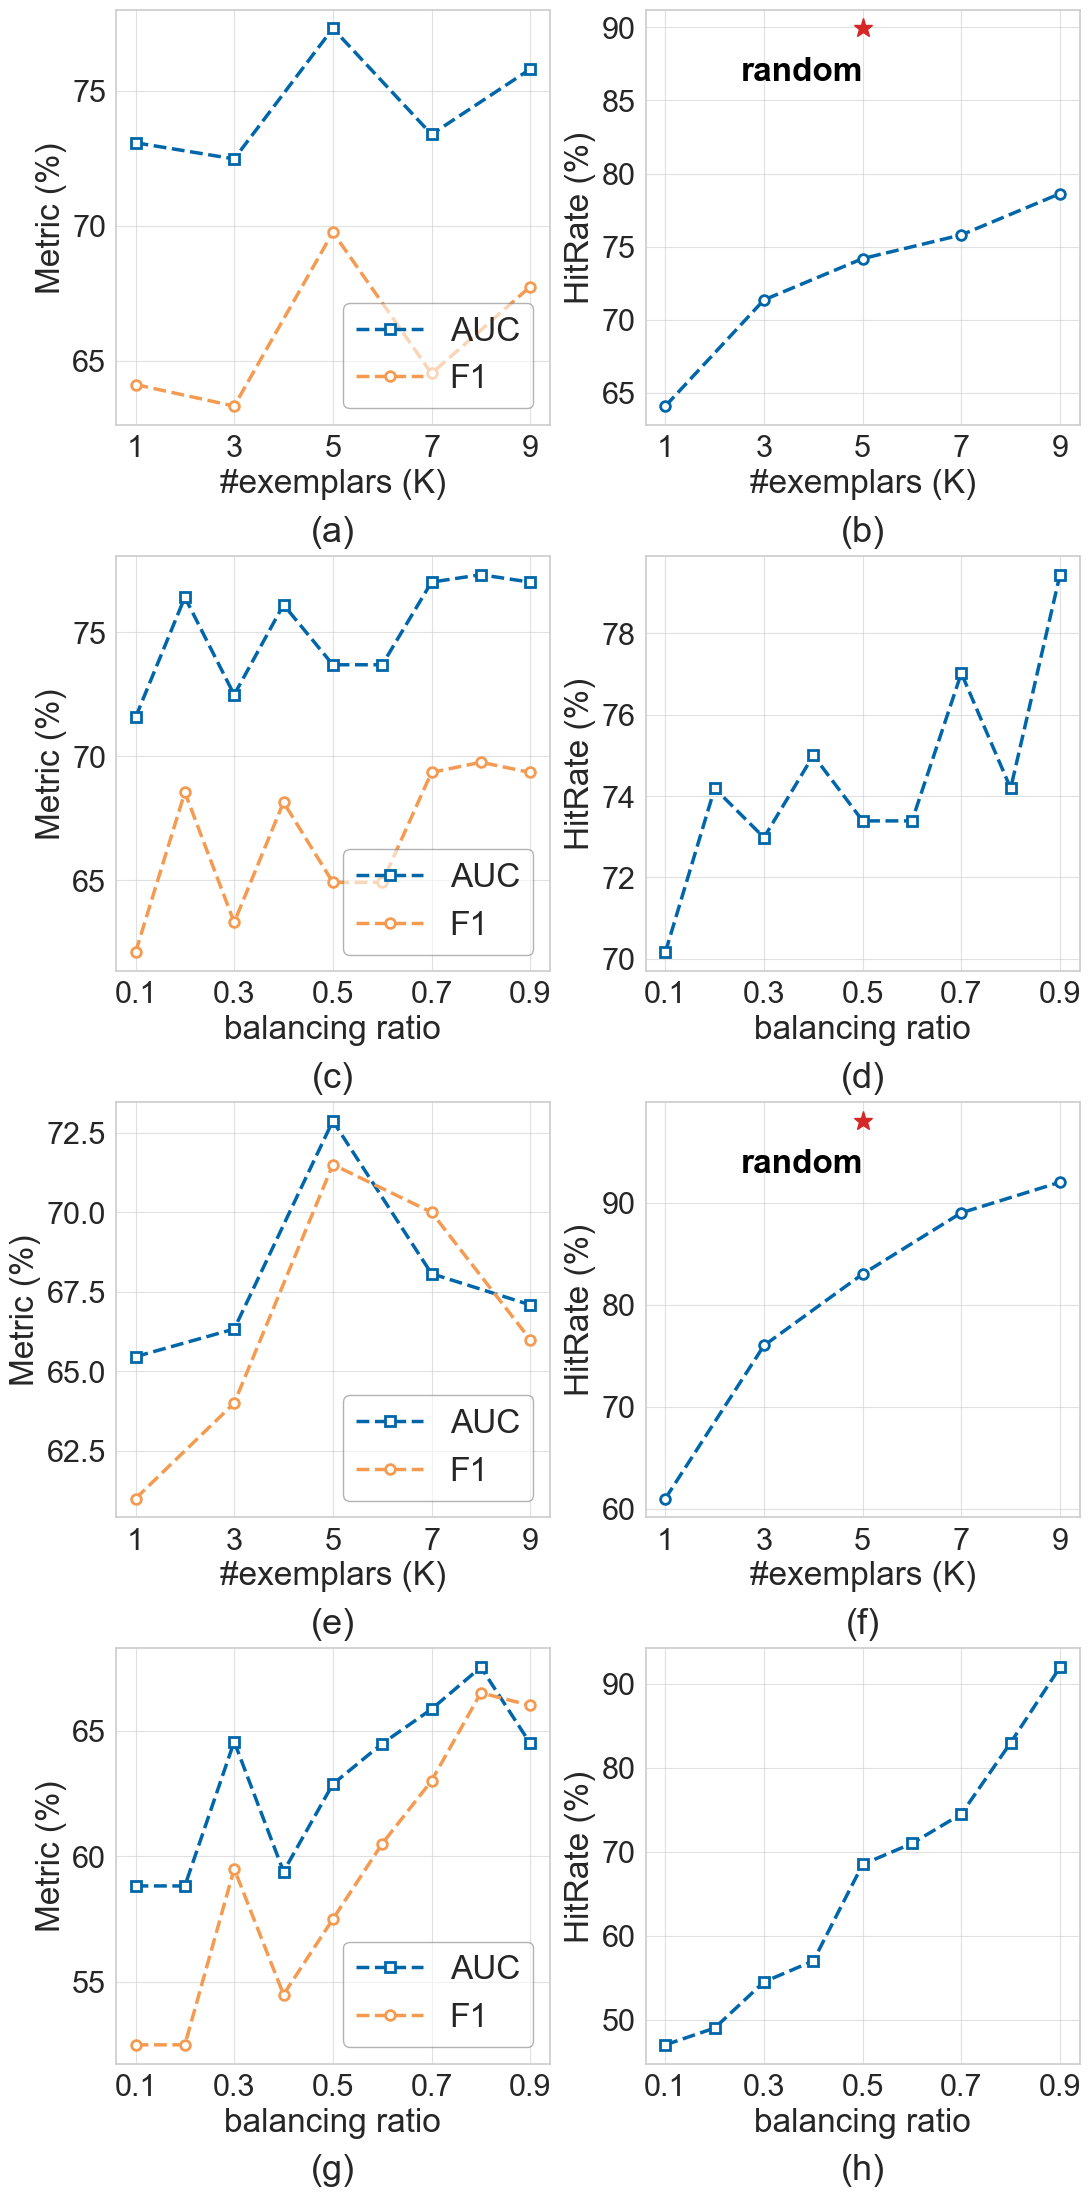

In [19]:
import matplotlib.pyplot as plt

# 1. 全局学术风格设置
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.6
plt.rcParams['axes.linewidth'] = 1.2

# 2. 数据准备
x_int = [1, 3, 5, 7, 9]
x_float = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# --- 原有数据 ---
data_a = ([64.11, 63.31, 69.76, 64.52, 67.74], [73.08, 72.48, 77.32, 73.39, 75.81])
data_b = ([62.1, 68.55, 63.31, 68.15, 64.92, 64.92, 69.35, 69.76, 69.35],
          [71.57, 76.41, 72.48, 76.11, 73.69, 73.69, 77.02, 77.32, 77.02])
# 特殊数据 (b)
data_e = ([64.11, 71.37, 74.19, 75.81, 78.63], [64.11, 71.37, 89.92, 75.81, 78.63])

data_c = ([61.00, 64.00, 71.50, 70.00, 66.00], [65.46, 66.33, 72.87, 68.07, 67.09])
data_d = ([52.5, 52.5, 59.5, 54.5, 57.5, 60.5, 63, 66.5, 66],
          [58.82, 58.82, 64.56, 59.39, 62.87, 64.48, 65.85, 67.52, 64.49])
# 特殊数据 (f)
data_f = ([61, 76, 83, 89, 92], [61, 76, 98, 89, 92])

# --- 新增数据 (用于 d 和 h) ---
# 由于你只提供了一列Y值，这里假设它是AUC或主要指标
data_new_d = [70.16, 74.19, 72.98, 75.00, 73.39, 73.39, 77.02, 74.19, 79.44]
data_new_h = [47.00, 49.00, 54.50, 57.00, 68.50, 71.00, 74.50, 83.00, 92.00]


# 3. 创建 2x4 画布 (宽度增加)
fig, axs = plt.subplots(4, 2, figsize=(11, 22))

# ==========================================
# 通用绘图函数 (支持单线或双线)
# ==========================================
def draw_subplot(ax, x, y_blue, y_orange, x_label, sub_title, y_label, lenegd=True):
    # 绘制第一条线 (蓝色/AUC/Metric)
    ax.plot(x, y_blue, color='#0066aa', linestyle='--', linewidth=2.5,
            marker='s', markersize=7, markerfacecolor='white', markeredgewidth=2, label='AUC')

    # 如果有第二条线 (F1)，则绘制
    if y_orange is not None:
        ax.plot(x, y_orange, color='#f59b51', linestyle='--', linewidth=2.5,
                marker='o', markersize=7, markerfacecolor='white', markeredgewidth=2, label='F1')

    ax.set_ylabel(y_label, fontsize=24)
    ax.set_xlabel(x_label, fontsize=24)
    ax.tick_params(labelsize=22)
    ax.set_title(sub_title, y=-0.3, fontsize=26)

    if lenegd:
        ax.legend(loc='lower right', ncol=1, fontsize=24, frameon=True,
                  edgecolor='gray', framealpha=0.6)

# ==========================================
# 特殊绘图函数 (带Random标注)
# ==========================================
def draw_special_subplot(ax, x, y_line, y_special_list, x_label, sub_title):
    # 1. 绘制主曲线
    ax.plot(x, y_line, color='#0066aa', linestyle='--', linewidth=2.5,
            marker='o', markersize=7, markerfacecolor='white', markeredgewidth=2,
            label='Ours')

    # 2. 绘制异常点
    special_idx = 2
    special_x = x[special_idx]
    special_y = y_special_list[special_idx]

    ax.plot(special_x, special_y, color='#d62728', marker='*', markersize=14,
            linestyle='None', label='Random')

    # 3. 标注
    ax.annotate('random',
                xy=(special_x, special_y),
                xytext=(0, -20),
                textcoords='offset points',
                arrowprops=dict(facecolor='black', arrowstyle='->', shrinkB=5),
                fontsize=24,
                ha='right', va='top', fontweight='bold', color='black')

    ax.set_ylabel("HitRate (%)", fontsize=24)
    ax.set_xlabel(x_label, fontsize=24)
    ax.tick_params(labelsize=22)
    ax.set_title(sub_title, y=-0.3, fontsize=26)
    # ax.legend(loc='lower right', ncol=1, fontsize=11, frameon=True,
    #           edgecolor='gray', framealpha=0.6)

# 4. 填充子图 (2行4列)

# --- 第一行 ---
# (a) 原数据 a
draw_subplot(axs[0, 0], x_int, data_a[1], data_a[0], "#exemplars (K)", "(a)", "Metric (%)")

# (b) 特殊数据 e (原代码逻辑中的特殊图)
draw_special_subplot(axs[0, 1], x_int, data_e[0], data_e[1], "#exemplars (K)", "(b)")

# (c) 原数据 b
draw_subplot(axs[1, 0], x_float, data_b[1], data_b[0], "balancing ratio", "(c)", "Metric (%)")

# (d) 新增数据 1
# y_orange=None 表示只画一条线
draw_subplot(axs[1, 1], x_float, data_new_d, None, "balancing ratio", "(d)", "HitRate (%)", lenegd=False)


# --- 第二行 ---
# (e) 原数据 c (顺延)
draw_subplot(axs[2, 0], x_int, data_c[1], data_c[0], "#exemplars (K)", "(e)", "Metric (%)")

# (f) 特殊数据 f (原代码逻辑中的第二个特殊图)
draw_special_subplot(axs[2, 1], x_int, data_f[0], data_f[1], "#exemplars (K)", "(f)")

# (g) 原数据 d (顺延)
draw_subplot(axs[3, 0], x_float, data_d[1], data_d[0], "balancing ratio", "(g)", "Metric (%)")

# (h) 新增数据 2
draw_subplot(axs[3, 1], x_float, data_new_h, None, "balancing ratio", "(h)", "HitRate (%)", lenegd=False)


# 5. 精细化 X 轴刻度
# 整数轴: 列 0 和 列 1
for r in [0, 2]:
    for c in [0, 1]:
        axs[r, c].set_xticks(x_int)

# 小数轴: 列 2 和 列 3
for r in [1, 3]:
    for c in [0, 1]:
        axs[r, c].set_xticks([0.1, 0.3, 0.5, 0.7, 0.9])

# 6. 调整布局
# 增加 wspace 以防止子图太挤
plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.05, wspace=0.2, hspace=0.3)

plt.tight_layout()
plt.savefig("params.pdf")
plt.show()

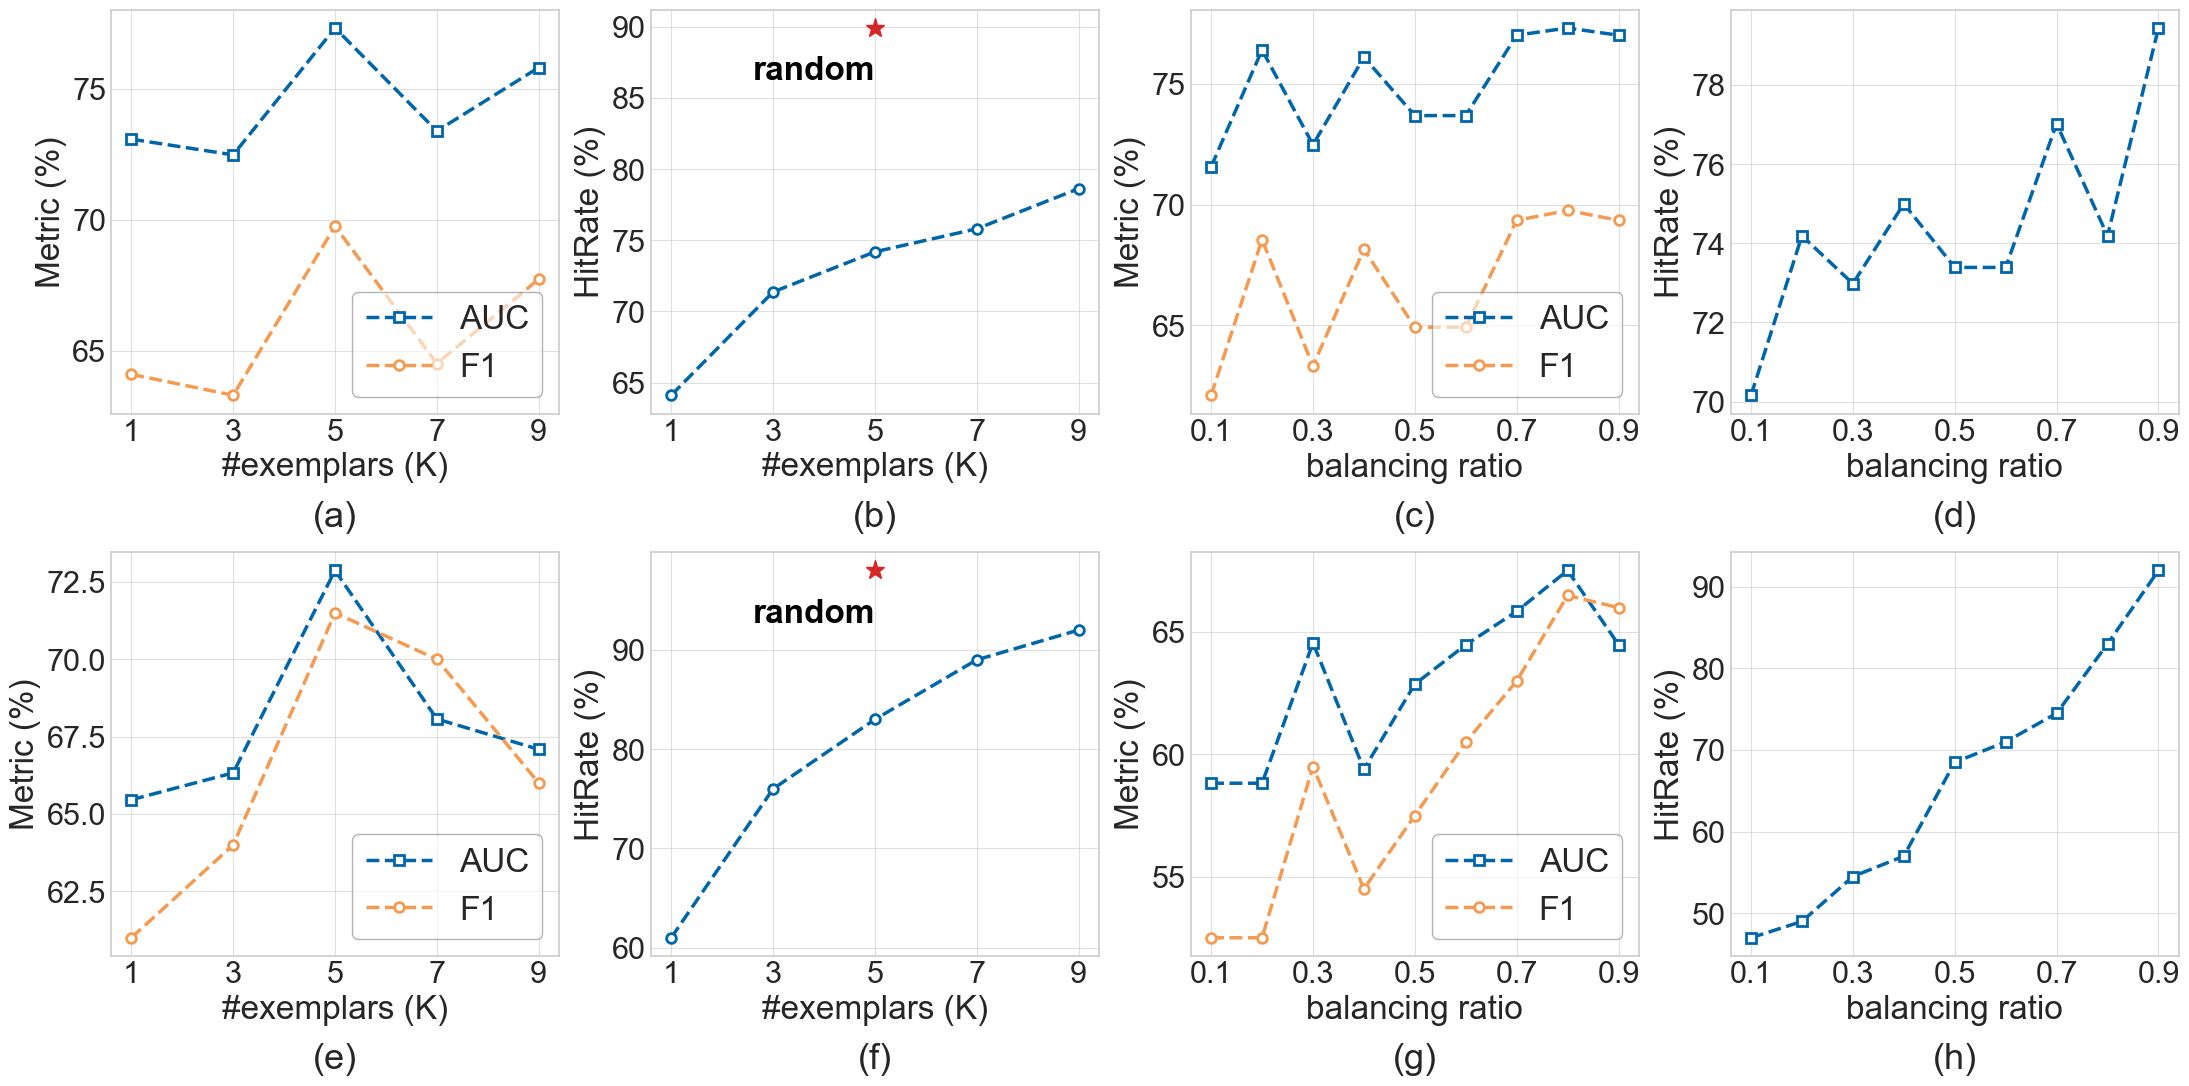

In [24]:
import matplotlib.pyplot as plt

# 1. 全局学术风格设置
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.6
plt.rcParams['axes.linewidth'] = 1.2

# 2. 数据准备
x_int = [1, 3, 5, 7, 9]
x_float = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# --- 原有数据 ---
data_a = ([64.11, 63.31, 69.76, 64.52, 67.74], [73.08, 72.48, 77.32, 73.39, 75.81])
data_b = ([62.1, 68.55, 63.31, 68.15, 64.92, 64.92, 69.35, 69.76, 69.35],
          [71.57, 76.41, 72.48, 76.11, 73.69, 73.69, 77.02, 77.32, 77.02])
# 特殊数据 (b)
data_e = ([64.11, 71.37, 74.19, 75.81, 78.63], [64.11, 71.37, 89.92, 75.81, 78.63])

data_c = ([61.00, 64.00, 71.50, 70.00, 66.00], [65.46, 66.33, 72.87, 68.07, 67.09])
data_d = ([52.5, 52.5, 59.5, 54.5, 57.5, 60.5, 63, 66.5, 66],
          [58.82, 58.82, 64.56, 59.39, 62.87, 64.48, 65.85, 67.52, 64.49])
# 特殊数据 (f)
data_f = ([61, 76, 83, 89, 92], [61, 76, 98, 89, 92])

# --- 新增数据 (用于 d 和 h) ---
# 由于你只提供了一列Y值，这里假设它是AUC或主要指标
data_new_d = [70.16, 74.19, 72.98, 75.00, 73.39, 73.39, 77.02, 74.19, 79.44]
data_new_h = [47.00, 49.00, 54.50, 57.00, 68.50, 71.00, 74.50, 83.00, 92.00]


# 3. 创建 2x4 画布 (宽度增加)
fig, axs = plt.subplots(2, 4, figsize=(22, 11))

# ==========================================
# 通用绘图函数 (支持单线或双线)
# ==========================================
def draw_subplot(ax, x, y_blue, y_orange, x_label, sub_title, y_label, lenegd=True):
    # 绘制第一条线 (蓝色/AUC/Metric)
    ax.plot(x, y_blue, color='#0066aa', linestyle='--', linewidth=2.5,
            marker='s', markersize=7, markerfacecolor='white', markeredgewidth=2, label='AUC')

    # 如果有第二条线 (F1)，则绘制
    if y_orange is not None:
        ax.plot(x, y_orange, color='#f59b51', linestyle='--', linewidth=2.5,
                marker='o', markersize=7, markerfacecolor='white', markeredgewidth=2, label='F1')

    ax.set_ylabel(y_label, fontsize=24)
    ax.set_xlabel(x_label, fontsize=24)
    ax.tick_params(labelsize=22)
    ax.set_title(sub_title, y=-0.3, fontsize=26)

    if lenegd:
        ax.legend(loc='lower right', ncol=1, fontsize=24, frameon=True,
                  edgecolor='gray', framealpha=0.6)

# ==========================================
# 特殊绘图函数 (带Random标注)
# ==========================================
def draw_special_subplot(ax, x, y_line, y_special_list, x_label, sub_title):
    # 1. 绘制主曲线
    ax.plot(x, y_line, color='#0066aa', linestyle='--', linewidth=2.5,
            marker='o', markersize=7, markerfacecolor='white', markeredgewidth=2,
            label='Ours')

    # 2. 绘制异常点
    special_idx = 2
    special_x = x[special_idx]
    special_y = y_special_list[special_idx]

    ax.plot(special_x, special_y, color='#d62728', marker='*', markersize=14,
            linestyle='None', label='Random')

    # 3. 标注
    ax.annotate('random',
                xy=(special_x, special_y),
                xytext=(0, -20),
                textcoords='offset points',
                arrowprops=dict(facecolor='black', arrowstyle='->', shrinkB=5),
                fontsize=24,
                ha='right', va='top', fontweight='bold', color='black')

    ax.set_ylabel("HitRate (%)", fontsize=24)
    ax.set_xlabel(x_label, fontsize=24)
    ax.tick_params(labelsize=22)
    ax.set_title(sub_title, y=-0.3, fontsize=26)
    # ax.legend(loc='lower right', ncol=1, fontsize=11, frameon=True,
    #           edgecolor='gray', framealpha=0.6)

# 4. 填充子图 (2行4列)

# --- 第一行 ---
# (a) 原数据 a
draw_subplot(axs[0, 0], x_int, data_a[1], data_a[0], "#exemplars (K)", "(a)", "Metric (%)")

# (b) 特殊数据 e (原代码逻辑中的特殊图)
draw_special_subplot(axs[0, 1], x_int, data_e[0], data_e[1], "#exemplars (K)", "(b)")

# (c) 原数据 b
draw_subplot(axs[0, 2], x_float, data_b[1], data_b[0], "balancing ratio", "(c)", "Metric (%)")

# (d) 新增数据 1
# y_orange=None 表示只画一条线
draw_subplot(axs[0, 3], x_float, data_new_d, None, "balancing ratio", "(d)", "HitRate (%)", lenegd=False)


# --- 第二行 ---
# (e) 原数据 c (顺延)
draw_subplot(axs[1, 0], x_int, data_c[1], data_c[0], "#exemplars (K)", "(e)", "Metric (%)")

# (f) 特殊数据 f (原代码逻辑中的第二个特殊图)
draw_special_subplot(axs[1, 1], x_int, data_f[0], data_f[1], "#exemplars (K)", "(f)")

# (g) 原数据 d (顺延)
draw_subplot(axs[1, 2], x_float, data_d[1], data_d[0], "balancing ratio", "(g)", "Metric (%)")

# (h) 新增数据 2
draw_subplot(axs[1, 3], x_float, data_new_h, None, "balancing ratio", "(h)", "HitRate (%)", lenegd=False)


# 5. 精细化 X 轴刻度
# 整数轴: 列 0 和 列 1
for r in [0, 1]:
    for c in [0, 1]:
        axs[r, c].set_xticks(x_int)

# 小数轴: 列 2 和 列 3
for r in [0, 1]:
    for c in [2, 3]:
        axs[r, c].set_xticks([0.1, 0.3, 0.5, 0.7, 0.9])

# 6. 调整布局
# 增加 wspace 以防止子图太挤
plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.05, wspace=0.2, hspace=0.3)

plt.tight_layout()
plt.savefig("params.pdf")
plt.show()